# Preparing Text for LLMs

Download, clean, and tokenize *The Time Machine* by H.G. Wells (Project Gutenberg). Goal: a word-level vocabulary with integer encode/decode.

In [93]:
import numpy as np
import requests
import re
import random
import matplotlib.pyplot as plt

## 1. Download

In [94]:
response = requests.get('https://www.gutenberg.org/files/35/35-0.txt')
text = response.content.decode('utf-8')

print(f'Downloaded {len(text):,} characters')
text[:1000]

Downloaded 182,973 characters


'*** START OF THE PROJECT GUTENBERG EBOOK 35 ***\r\n\r\n\r\n\r\n\r\nThe Time Machine\r\n\r\nAn Invention\r\n\r\nby H. G. Wells\r\n\r\n\r\nCONTENTS\r\n\r\n I Introduction\r\n II The Machine\r\n III The Time Traveller Returns\r\n IV Time Travelling\r\n V In the Golden Age\r\n VI The Sunset of Mankind\r\n VII A Sudden Shock\r\n VIII Explanation\r\n IX The Morlocks\r\n X When Night Came\r\n XI The Palace of Green Porcelain\r\n XII In the Darkness\r\n XIII The Trap of the White Sphinx\r\n XIV The Further Vision\r\n XV The Time Traveller’s Return\r\n XVI After the Story\r\n Epilogue\r\n\r\n\r\n\r\n\r\n I.\r\n Introduction\r\n\r\n\r\nThe Time Traveller (for so it will be convenient to speak of him) was\r\nexpounding a recondite matter to us. His pale grey eyes shone and\r\ntwinkled, and his usually pale face was flushed and animated. The fire\r\nburnt brightly, and the soft radiance of the incandescent lights in the\r\nlilies of silver caught the bubbles that flashed and passed in our\r\nglas

## 2. Clean

In [95]:
def clean_text(text, strip_gutenberg=True):
    if strip_gutenberg:
        start = text.find('*** START OF THE PROJECT GUTENBERG')
        end   = text.find('*** END OF THE PROJECT GUTENBERG')
        if start != -1:
            text = text[text.index('\n', start):end]

    text = text.replace('\r\n', '\n').replace('_', ' ')
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).lower().strip()
    return text

In [96]:
text = clean_text(text)
text[:500]

'the time machine an invention by h. g. wells contents i introduction ii the machine iii the time traveller returns iv time travelling v in the golden age vi the sunset of mankind vii a sudden shock viii explanation ix the morlocks x when night came xi the palace of green porcelain xii in the darkness xiii the trap of the white sphinx xiv the further vision xv the time traveller s return xvi after the story epilogue i. introduction the time traveller (for so it will be convenient to speak of him)'

## 3. Tokenize

In [97]:
def tokenize(text):
    words = re.split(r'[^a-z]+', text)
    return [w for w in words if len(w) > 1]

In [98]:
words  = tokenize(text)
nWords = len(words)

print(f'{nWords:,} total words')
words[:20]

30,686 total words


['the',
 'time',
 'machine',
 'an',
 'invention',
 'by',
 'wells',
 'contents',
 'introduction',
 'ii',
 'the',
 'machine',
 'iii',
 'the',
 'time',
 'traveller',
 'returns',
 'iv',
 'time',
 'travelling']

## 4. Vocabulary

In [99]:
vocab = sorted(set(words))
nLex  = len(vocab)

print(f'{nWords:,} words, {nLex:,} unique tokens')

30,686 words, 4,586 unique tokens


## 5. Encode & Decode

In [100]:
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = dict(enumerate(vocab))

list(word2idx.items())[:10]

[('abandon', 0),
 ('abandoned', 1),
 ('able', 2),
 ('abnormally', 3),
 ('abominable', 4),
 ('abominations', 5),
 ('about', 6),
 ('above', 7),
 ('abruptly', 8),
 ('absence', 9)]

In [101]:
def encode(words, vocab=vocab):
    w2i = {w: i for i, w in enumerate(vocab)}
    return np.array([w2i[w] for w in words], dtype=int)

def decode(indices, vocab=vocab):
    i2w = dict(enumerate(vocab))
    return ' '.join(i2w[i] for i in indices)

In [102]:
def encode_unk(words, vocab=vocab):
    w2i = {w: i for i, w in enumerate(vocab)}
    unk  = len(vocab) + 1
    return np.array([w2i.get(w, unk) for w in words], dtype=int)

In [103]:
def decode_unk(indices, vocab=vocab):
    i2w = dict(enumerate(vocab))
    return ' '.join(i2w.get(i, '<|unk|>') for i in indices)

In [104]:
print(encode(['the', 'time', 'machine']))
print(decode([1, 3, 10]))

print(encode_unk(['the', 'time', 'zorblax']))
print(decode_unk(encode_unk(['the', 'time', 'zorblax'])))

[4039 4106 2414]
abandoned abnormally absent
[4039 4106 4587]
the time <|unk|>


In [105]:
start  = np.random.randint(nWords - 10)
sample = words[start:start + 10]

encoded = encode(sample)
decoded = decode(encoded)

print('Original:', sample)
print('Indices: ', encoded)
print('Decoded: ', decoded)
assert sample == decoded.split(), 'Roundtrip failed!'

Original: ['one', 'little', 'white', 'lever', 'and', 'here', 'is', 'another', 'the', 'medical']
Indices:  [2740 2366 4475 2322  137 1900 2181  151 4039 2479]
Decoded:  one little white lever and here is another the medical


In [106]:
random_tokens = np.random.randint(0, len(vocab), 10)
print(f'Random tokens: {random_tokens}')
print(f'Decoded:       {decode(random_tokens, vocab)}')

Random tokens: [3636  830 2098 1296 2327 1442 2943 1375 3032  859]
Decoded:       sleepy crab inhuman even lichens fed placed extinction press crowbar


## 6. Brownian Noise Walk

In [107]:
def generate_brownian_noise(sequence_len=10):
    steps = [random.choice([-1, 1]) for _ in range(sequence_len)]
    noise, cumsum = [], 0
    for s in steps:
        cumsum += s
        noise.append(cumsum)
    return noise

In [108]:
noisy_sample = generate_brownian_noise(29)
initial_token = np.random.randint(abs(min(noisy_sample)), len(vocab))
noisy_tokens  = [x + initial_token for x in noisy_sample]
decode_unk(noisy_tokens)

'hopes hopelessly hopes hopping horizon hopping horizon horizontal horizon horizontal horizon hopping hopes hopping hopes hopelessly hopeless hoped hope hoped hopeless hopelessly hopeless hopelessly hopeless hopelessly hopeless hopelessly hopeless'

## 7. Word Length Analysis

In [109]:
word_vocab_len = np.array([len(w) for w in vocab])
word_text_len = np.array([len(w) for w in words])

Text(0.5, 1.0, 'Word length by vocabulary index')

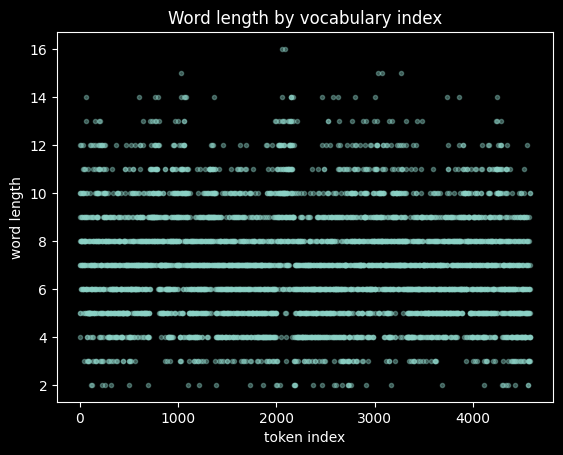

In [110]:
plt.plot(word_vocab_len, 'o', markersize=3, alpha=0.4)
plt.xlabel('token index')
plt.ylabel('word length')
plt.title('Word length by vocabulary index')

Text(0.5, 1.0, 'Distribution of word lengths in vocabulary')

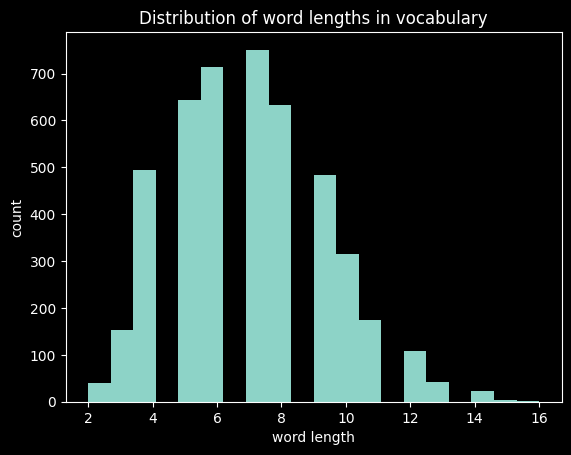

In [111]:
plt.hist(word_vocab_len, bins=20)
plt.xlabel('word length')
plt.ylabel('count')
plt.title('Distribution of word lengths in vocabulary')

Text(0.5, 1.0, 'Word length by word index')

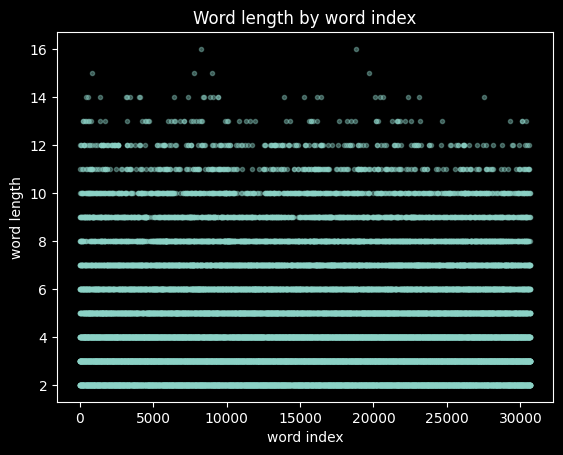

In [112]:
plt.plot(word_text_len, 'o', markersize=3, alpha=0.4)
plt.xlabel('word index')
plt.ylabel('word length')
plt.title('Word length by word index')

Text(0.5, 1.0, 'Distribution of word lengths in whole text')

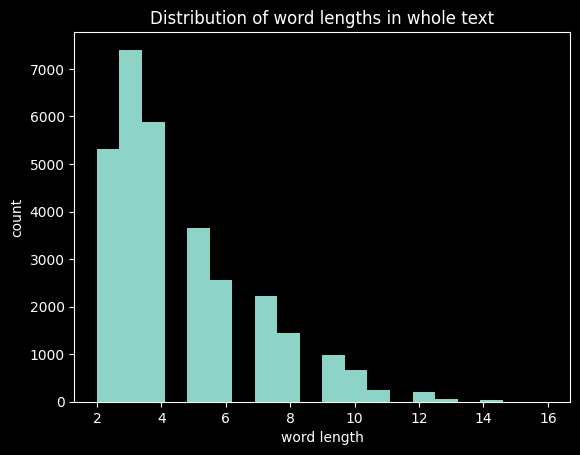

In [113]:
plt.hist(word_text_len, bins=20)
plt.xlabel('word length')
plt.ylabel('count')
plt.title('Distribution of word lengths in whole text')

## 8. Out-of-Vocabulary Handling

In [114]:
new_sentence = 'The aliens abandoned the fruits in the beach.'
words_new = tokenize(clean_text(new_sentence, strip_gutenberg=False))

In [115]:
encode_unk(words_new, vocab)

array([4039, 4587,    1, 4039, 1643, 2039, 4039,  320])

In [116]:
decode_unk(encode_unk(words_new, vocab))

'the <|unk|> abandoned the fruits in the beach'